<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Catalina_Nunez_Churn_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Fuga de Clientes (Churn)
**BIY7121 Minería de Datos — DuocUC**  
**Alumna:** Catalina Núñez Yáñez

## 1. Business Understanding

Una empresa de telecomunicaciones en California quiere saber qué clientes están en riesgo de irse antes de que lo hagan. Tienen datos de 7.043 usuarios y el objetivo es identificar patrones que permitan actuar a tiempo.

Perder un cliente sale caro — conseguir uno nuevo es mucho más caro que retener uno actual. Por eso tiene sentido invertir en un modelo que prediga el churn con anticipación.

Las variables que deberían importar más:
- **Contract**: si el contrato es mes a mes, el cliente se puede ir cuando quiera
- **tenure**: a más tiempo en la empresa, menos probable que se vaya
- **MonthlyCharges**: si paga mucho y no ve valor, probablemente se va
- **InternetService**: los de fibra óptica tienen más opciones en el mercado

## 2. Carga de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 7043, Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Nota: TotalCharges aparece como object en vez de número. Esto pasa porque algunas filas tienen un espacio en blanco en esa columna. Hay que convertirla manualmente.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('TotalCharges convertida a:', df['TotalCharges'].dtype)

TotalCharges convertida a: float64


## 3. Data Understanding — EDA

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Nota: Solo TotalCharges tiene 11 nulos. Son clientes nuevos con tenure=0 que todavía no tienen cobros registrados. Como son solo 11 filas de 7043, los eliminamos sin problema.

In [8]:
df.dropna(inplace=True)
print(f'Dataset después de limpiar: {df.shape[0]} filas')

Dataset después de limpiar: 7032 filas


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Porcentaje de fuga: 26.6%


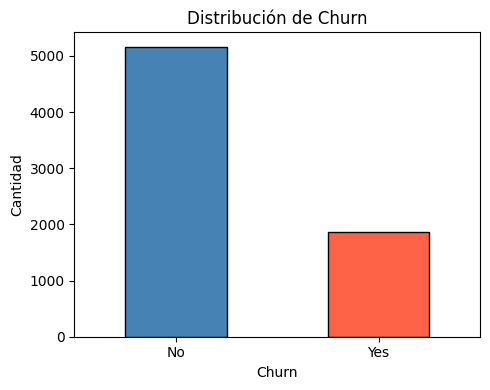

In [9]:
print(df['Churn'].value_counts())
print(f'\nPorcentaje de fuga: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nota: Solo el 26.6% de los clientes hizo churn. Hay un desbalance claro — más adelante lo vamos a tratar con SMOTE para que los modelos no aprendan a predecir siempre "no se va".

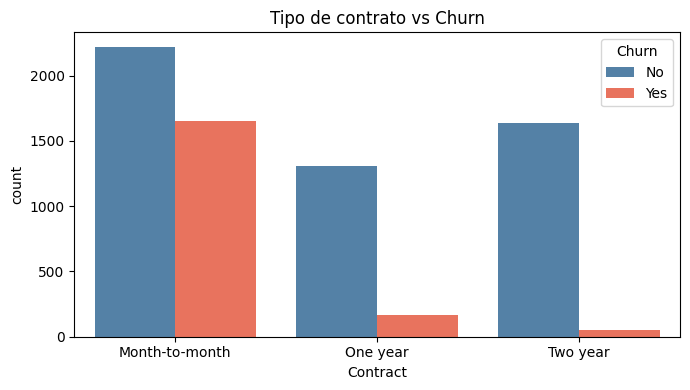

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue','tomato'])
plt.title('Tipo de contrato vs Churn')
plt.tight_layout()
plt.show()

Nota: Los clientes con contrato mes a mes son los que más se van. Los que tienen contrato de 1 o 2 años casi no hacen churn — tiene sentido porque tienen un compromiso firmado.

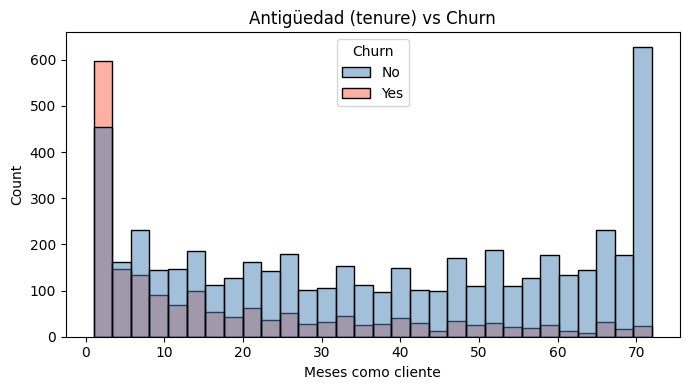

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue','tomato'])
plt.title('Antigüedad (tenure) vs Churn')
plt.xlabel('Meses como cliente')
plt.tight_layout()
plt.show()

Nota: La mayoría de los que se van llevan menos de 12 meses en la empresa. Los clientes más antiguos tienden a quedarse.

In [12]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


### 3.1 Detección de Outliers — Boxplots e IQR

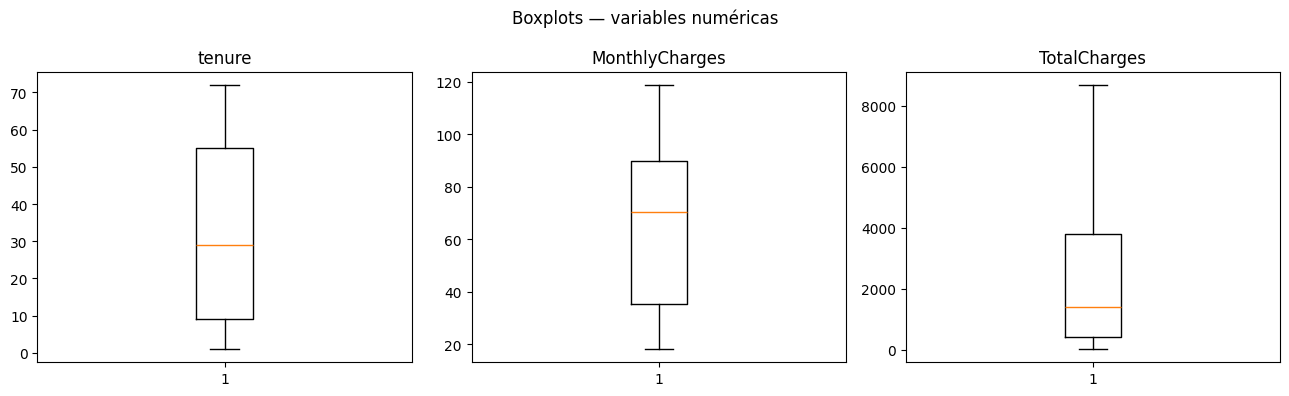

In [13]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.suptitle('Boxplots — variables numéricas')
plt.tight_layout()
plt.show()

In [14]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = len(df[(df[col] < lim_inf) | (df[col] > lim_sup)])
    print(f'{col}: {n_outliers} outliers | rango normal [{lim_inf:.1f}, {lim_sup:.1f}]')

tenure: 0 outliers | rango normal [-60.0, 124.0]
MonthlyCharges: 0 outliers | rango normal [-45.8, 171.3]
TotalCharges: 0 outliers | rango normal [-4688.5, 8884.7]


Nota: No hay outliers fuera del rango IQR. Los valores altos en TotalCharges o MonthlyCharges son simplemente clientes que llevan mucho tiempo o tienen planes premium — son datos válidos, no errores.

### 3.2 Matriz de Correlación

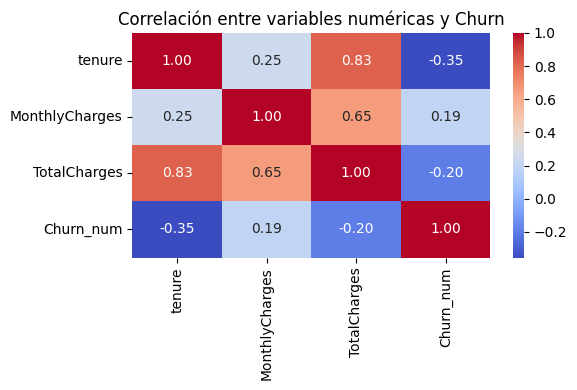

In [15]:
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

corr = df_corr[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables numéricas y Churn')
plt.tight_layout()
plt.show()

Nota: tenure tiene correlación negativa con Churn (-0.35) — a más meses en la empresa, menos probable que se vaya. MonthlyCharges tiene correlación positiva (0.19) — los que pagan más tienden a irse más.

## 4. Data Preparation

In [16]:
# Sacamos customerID, no sirve para modelar
df_model = df.drop(columns=['customerID'])

X = df_model.drop(columns=['Churn'])
y = (df_model['Churn'] == 'Yes').astype(int)

print('Variables:', X.shape[1])
print(y.value_counts())

Variables: 19
Churn
0    5163
1    1869
Name: count, dtype: int64


In [17]:
# Label Encoding para columnas con solo 2 valores posibles
le = LabelEncoder()
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies']

for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# One-Hot Encoding para columnas con más de 2 categorías
X = pd.get_dummies(X, columns=['InternetService','Contract','PaymentMethod'], drop_first=True)

print('Columnas después de transformar:', X.shape[1])

Columnas después de transformar: 23


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 4922 | Test: 2110


In [19]:
# StandardScaler pone todas las variables en la misma escala
# Necesario para SVM y Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### 4.1 Manejo del desbalance de clases — SMOTE

El dataset tiene 74% de clientes que no hicieron churn y solo 26% que sí. Si lo dejamos así, los modelos aprenden a predecir siempre "no se va" y igual tienen buen accuracy — pero eso no sirve de nada.

SMOTE crea ejemplos sintéticos de la clase minoritaria (los que se van) para equilibrar el dataset antes de entrenar.

In [20]:
print('Antes de SMOTE:')
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\nDespués de SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Antes de SMOTE:
Churn
0    3614
1    1308
Name: count, dtype: int64

Después de SMOTE:
Churn
1    3614
0    3614
Name: count, dtype: int64


## 5. Modeling & Evaluation

In [21]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)

    print(f'\n--- {nombre} ---')
    print(f'Accuracy: {accuracy_score(y_te, pred):.4f}')
    print(f'F1-Score: {f1_score(y_te, pred):.4f}')
    print(classification_report(y_te, pred, target_names=['Se queda','Se va']))

    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: queda','Pred: se va'],
                yticklabels=['Real: queda','Real: se va'])
    plt.title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()

    return modelo, accuracy_score(y_te, pred), f1_score(y_te, pred), pred

### 5.1 Regresión Logística


--- Regresión Logística ---
Accuracy: 0.7412
F1-Score: 0.6171
              precision    recall  f1-score   support

    Se queda       0.90      0.73      0.80      1549
       Se va       0.51      0.78      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.75      0.71      2110
weighted avg       0.80      0.74      0.75      2110



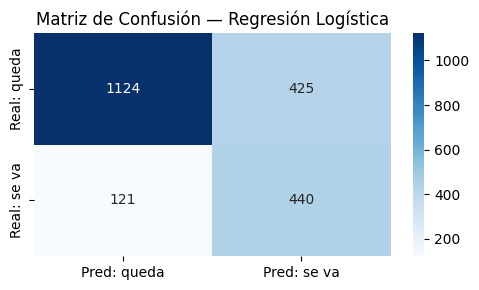

In [22]:
# Modelo simple pero interpretable, ideal para empezar
lr = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr_model, lr_acc, lr_f1, lr_pred = evaluar('Regresión Logística', lr, X_train_sm, y_train_sm, X_test_scaled, y_test)

### 5.2 SVM


--- SVM ---
Accuracy: 0.7616
F1-Score: 0.6169
              precision    recall  f1-score   support

    Se queda       0.89      0.78      0.83      1549
       Se va       0.54      0.72      0.62       561

    accuracy                           0.76      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.79      0.76      0.77      2110



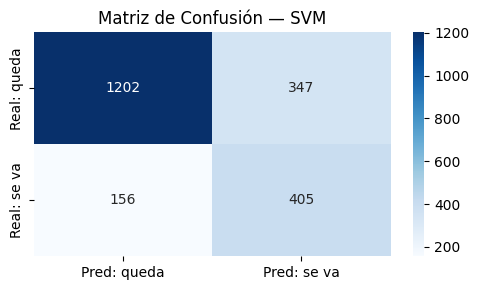

In [23]:
# SVM busca el mejor límite para separar las dos clases
# Requiere datos escalados — ya lo hicimos con StandardScaler
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model, svm_acc, svm_f1, svm_pred = evaluar('SVM', svm, X_train_sm, y_train_sm, X_test_scaled, y_test)

### 5.3 Árbol de Decisión


--- Árbol de Decisión ---
Accuracy: 0.7318
F1-Score: 0.5863
              precision    recall  f1-score   support

    Se queda       0.88      0.74      0.80      1549
       Se va       0.50      0.71      0.59       561

    accuracy                           0.73      2110
   macro avg       0.69      0.73      0.69      2110
weighted avg       0.78      0.73      0.74      2110



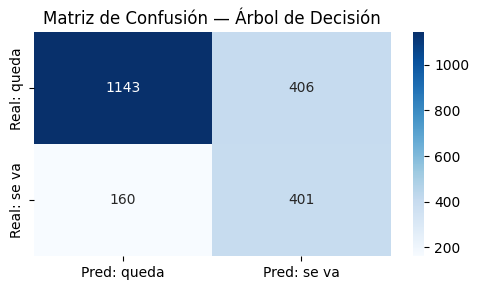

In [24]:
# El árbol hace preguntas tipo IF/ELSE hasta llegar a una predicción
# max_depth=5 para evitar que memorice los datos de entrenamiento
tree = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
tree_model, tree_acc, tree_f1, tree_pred = evaluar('Árbol de Decisión', tree, X_train_sm, y_train_sm, X_test_scaled, y_test)

### 5.4 Comparación de modelos

             Modelo  Accuracy  F1-Score
Regresión Logística  0.741232  0.617111
                SVM  0.761611  0.616908
  Árbol de Decisión  0.731754  0.586257


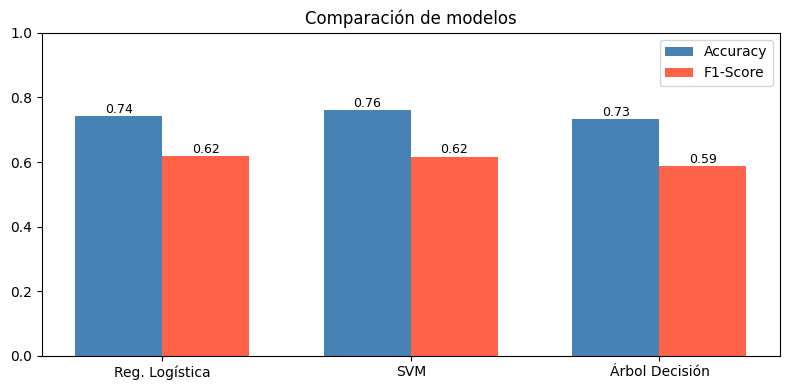

In [25]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Árbol de Decisión'],
    'Accuracy': [lr_acc, svm_acc, tree_acc],
    'F1-Score': [lr_f1, svm_f1, tree_f1]
})
print(resultados.to_string(index=False))

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8,4))
b1 = ax.bar(x - w/2, resultados['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, resultados['F1-Score'], w, label='F1-Score', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['Reg. Logística','SVM','Árbol Decisión'])
ax.set_ylim(0,1)
ax.legend()
ax.set_title('Comparación de modelos')
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Nota: SVM tiene el mejor accuracy (76.2%) pero los tres modelos quedan similares en F1. La Regresión Logística detecta más casos de churn real (Recall más alto), lo que en un contexto de negocio importa más que el accuracy general.

### 5.5 Variables que más influyen en la fuga

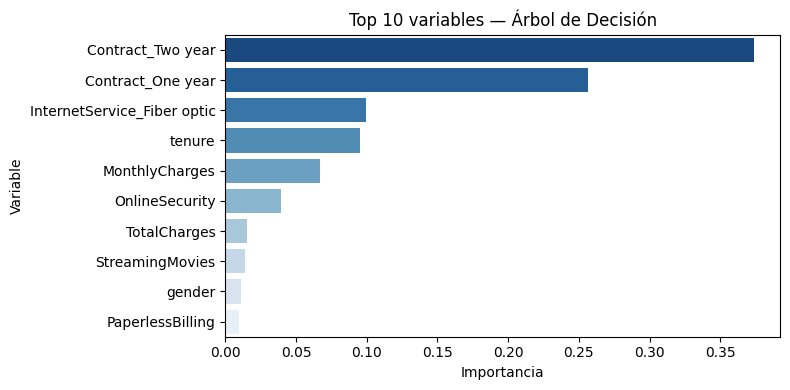

                   Variable  Importancia
          Contract_Two year     0.373470
          Contract_One year     0.256577
InternetService_Fiber optic     0.099676
                     tenure     0.095543
             MonthlyCharges     0.067024
             OnlineSecurity     0.039570
               TotalCharges     0.015558
            StreamingMovies     0.014098
                     gender     0.010922
           PaperlessBilling     0.009725


In [26]:
# Feature importance del árbol de decisión
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='Blues_r')
plt.title('Top 10 variables — Árbol de Decisión')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

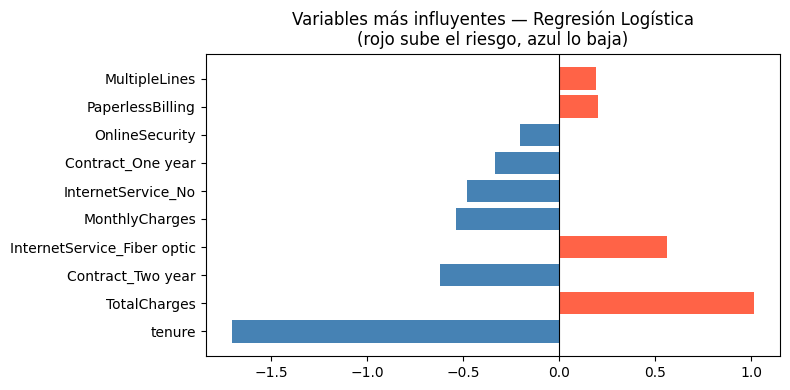

In [27]:
# Coeficientes de la Regresión Logística
# Positivo = sube el riesgo de irse, negativo = lo baja
coefs = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(10)

colores = ['tomato' if c > 0 else 'steelblue' for c in coefs['Coeficiente']]
plt.figure(figsize=(8,4))
plt.barh(coefs['Variable'], coefs['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables más influyentes — Regresión Logística\n(rojo sube el riesgo, azul lo baja)')
plt.tight_layout()
plt.show()

Nota: El tipo de contrato (Two year, One year) son las variables que más pesan en ambos modelos. Tener contrato largo baja mucho el riesgo de churn. La fibra óptica y los cargos mensuales altos lo suben.

## 6. Insights

**1. Contrato mes a mes = mayor riesgo**  
Es la variable más importante en los dos modelos. Un cliente sin contrato largo puede irse cuando quiera — y lo hace.

**2. Los clientes nuevos son los más vulnerables**  
La mayoría de los que hicieron churn llevan menos de un año. Pasado ese primer año, la probabilidad de irse baja bastante.

**3. Fibra óptica + contrato mensual = perfil de alto riesgo**  
Pagan más, tienen más opciones en el mercado y no tienen ningún compromiso. Es la combinación más peligrosa.

**4. Clientes que pagan mucho sin servicios adicionales**  
Si alguien paga un monto alto pero no tiene ningún servicio extra contratado (seguridad, soporte, backup), probablemente no percibe valor en lo que paga.

## 7. Métricas de Costo-Beneficio

In [28]:
# Retener un cliente cuesta $10, perderlo cuesta $100
COSTO_RETENCION = 10
COSTO_PERDIDA   = 100

def calcular_ahorro(y_real, y_pred, nombre):
    TN, FP, FN, TP = confusion_matrix(y_real, y_pred).ravel()
    ahorro = TP * (COSTO_PERDIDA - COSTO_RETENCION) - FP * COSTO_RETENCION - FN * COSTO_PERDIDA
    print(f'\n{nombre}')
    print(f'  TP (detectó que se iba y tenía razón): {TP}')
    print(f'  FP (falsa alarma, oferta innecesaria):  {FP}')
    print(f'  FN (se fue sin que lo detectáramos):   {FN}')
    print(f'  Ahorro neto: ${ahorro:,.0f}')
    return ahorro

a_lr  = calcular_ahorro(y_test, lr_pred,   'Regresión Logística')
a_svm = calcular_ahorro(y_test, svm_pred,  'SVM')
a_dt  = calcular_ahorro(y_test, tree_pred, 'Árbol de Decisión')


Regresión Logística
  TP (detectó que se iba y tenía razón): 440
  FP (falsa alarma, oferta innecesaria):  425
  FN (se fue sin que lo detectáramos):   121
  Ahorro neto: $23,250

SVM
  TP (detectó que se iba y tenía razón): 405
  FP (falsa alarma, oferta innecesaria):  347
  FN (se fue sin que lo detectáramos):   156
  Ahorro neto: $17,380

Árbol de Decisión
  TP (detectó que se iba y tenía razón): 401
  FP (falsa alarma, oferta innecesaria):  406
  FN (se fue sin que lo detectáramos):   160
  Ahorro neto: $16,030


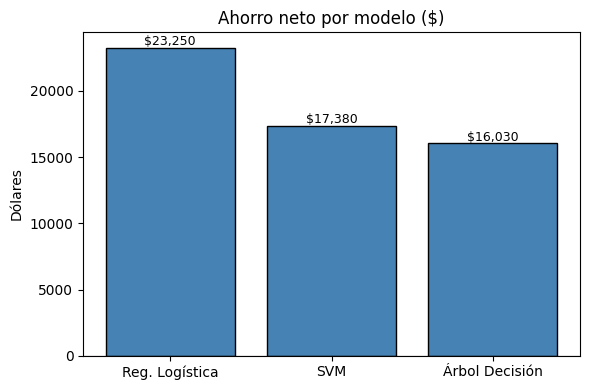

In [29]:
plt.figure(figsize=(6,4))
modelos = ['Reg. Logística','SVM','Árbol Decisión']
ahorros = [a_lr, a_svm, a_dt]
colores = ['steelblue' if a >= 0 else 'tomato' for a in ahorros]
plt.bar(modelos, ahorros, color=colores, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Ahorro neto por modelo ($)')
plt.ylabel('Dólares')
for i, v in enumerate(ahorros):
    plt.text(i, v+200, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Nota: La Regresión Logística genera el mayor ahorro neto porque detecta más casos de churn real (TP más alto). Aunque tiene más falsas alarmas que SVM, los $10 por oferta innecesaria son mucho menos costosos que los $100 por perder un cliente sin detectarlo.

## 8. Propuestas prácticas

**1. Ofrecer migración a contrato anual en los primeros 3 meses**  
Los clientes nuevos con contrato mes a mes son el grupo de mayor riesgo. Un descuento para migrar a contrato de 1 o 2 años en los primeros meses costaría menos que reemplazarlos después.

**2. Programa de retención para usuarios de fibra óptica sin servicios adicionales**  
Este perfil tiene probabilidad alta de irse. Ofrecerles un servicio extra gratis por 3 meses (seguridad online, soporte técnico) puede aumentar la percepción de valor y reducir el churn.

**3. Lista mensual de clientes en riesgo para el equipo de marketing**  
Usando el modelo de Regresión Logística, generar cada mes una lista de los clientes con probabilidad de churn mayor al 70%. El equipo puede contactarlos proactivamente antes de que decidan irse.